# Notebook 02: Treinamento do Classificador de Perfil Financeiro

Este notebook treina um modelo de Machine Learning (Random Forest) capaz de classificar o perfil financeiro de um usuario (`Saudavel`, `Em observacao`, `Em risco`) com base em suas caracteristicas socioeconomicas e financeiras.

In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [2]:
# ==========================================================
# PATHS LOCAIS
# ==========================================================

BASE = "../../data"
BASE_MODELS = "../../models"

import os
os.makedirs(BASE_MODELS, exist_ok=True)

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [4]:
# ==========================================================
# LEITURA DO DATASET
# ==========================================================

dataset_perfil = pd.read_csv(
    f"{BASE}/processed/dataset_modelo_perfil.csv"
)

dataset_perfil.head()

,usuario_id,idade,sexo,estado_civil,dependentes,cidade,estado,profissao,escolaridade,renda_mensal_x,...,perc_transporte,qtd_recorrentes,qtd_parceladas,perc_boleto,perc_cartão de crédito,perc_cartão de débito,perc_dinheiro,perc_débito automático,perc_pix,perc_transferência bancária
0,1,40,Masculino,Divorciado,2,Belo Horizonte,MG,Analista de TI,Médio,9214.53,...,0.050941,7,3,0.090909,0.295455,0.227273,0.022727,0.022727,0.204545,0.136364
1,2,41,Masculino,Solteiro,2,Duque de Caxias,RJ,Recepcionista,Fundamental,1812.22,...,0.001064,7,1,0.151515,0.393939,0.060606,0.030303,0.030303,0.212121,0.121212
2,3,40,Feminino,Casado,0,Guarulhos,SP,Analista de TI,Superior,7668.81,...,0.012108,12,0,0.074074,0.240741,0.166667,0.129630,0.074074,0.166667,0.148148
3,4,38,Masculino,Divorciado,4,Cuiabá,MT,Analista de TI,Superior,7828.20,...,0.016859,3,2,0.040000,0.280000,0.200000,0.000000,0.080000,0.160000,0.240000
4,5,27,Feminino,Solteiro,0,Maceió,AL,Empresário,Superior,21743.69,...,0.034179,14,0,0.040816,0.183673,0.142857,0.000000,0.102041,0.346939,0.183673


In [5]:
# ==========================================================
# VARIAVEL ALVO
# ==========================================================

y = dataset_perfil["perfil_financeiro"]

In [6]:
# ==========================================================
# FEATURES UTILIZADAS
# ==========================================================

X = dataset_perfil.drop(
    columns=[
        "usuario_id",
        "perfil_financeiro",
        "cidade",
        "estado",
        "profissao"
    ]
)

In [7]:
# ==========================================================
# COLUNAS CATEGORICAS
# ==========================================================

categoricas = [
    "sexo",
    "estado_civil",
    "escolaridade",
    "frequencia_poupanca"
]

numericas = [c for c in X.columns if c not in categoricas]

In [8]:
# ==========================================================
# ONE HOT ENCODER
# ==========================================================

preprocessador = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categoricas)
    ],
    remainder="passthrough"
)

In [9]:
# ==========================================================
# DIVISAO TREINO / TESTE
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
# ==========================================================
# PIPELINE
# ==========================================================

pipeline = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessamento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [11]:
# ==========================================================
# PREDICOES
# ==========================================================

predicoes = pipeline.predict(X_test)

In [12]:
# ==========================================================
# METRICAS
# ==========================================================

accuracy = accuracy_score(y_test, predicoes)
precision = precision_score(y_test, predicoes, average="macro")
recall = recall_score(y_test, predicoes, average="macro")
f1 = f1_score(y_test, predicoes, average="macro")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000


In [13]:
# ==========================================================
# AVALIACAO TREINO x TESTE
# ==========================================================

acc_treino = pipeline.score(X_train, y_train)
acc_teste = pipeline.score(X_test, y_test)

print(f"Acuracia Treino : {acc_treino:.4f}")
print(f"Acuracia Teste  : {acc_teste:.4f}")

Acuracia Treino : 1.0000
Acuracia Teste  : 1.0000


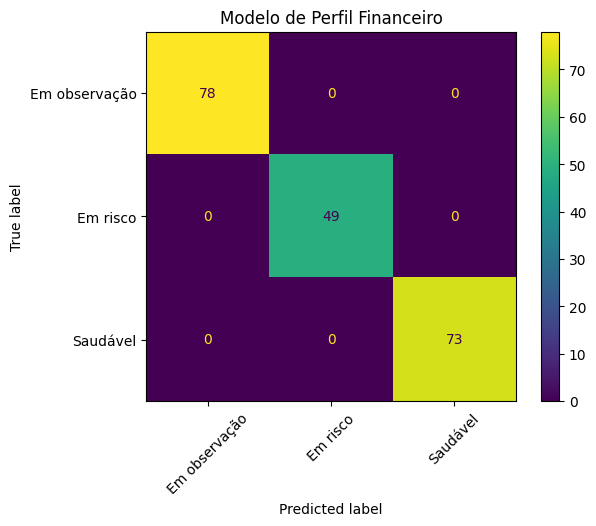

In [14]:
# ==========================================================
# MATRIZ DE CONFUSAO
# ==========================================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicoes,
    xticks_rotation=45
)
plt.title("Modelo de Perfil Financeiro")
plt.show()

In [15]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print(classification_report(y_test, predicoes, digits=4))

               precision    recall  f1-score   support

Em observação     1.0000    1.0000    1.0000        78
     Em risco     1.0000    1.0000    1.0000        49
     Saudável     1.0000    1.0000    1.0000        73

     accuracy                         1.0000       200
    macro avg     1.0000    1.0000    1.0000       200
 weighted avg     1.0000    1.0000    1.0000       200



In [16]:
# ==========================================================
# SALVANDO O MODELO 2
# ==========================================================

joblib.dump(pipeline, f"{BASE_MODELS}/modelo_perfil.joblib")

print("Modelo salvo com sucesso.")

Modelo salvo com sucesso.


In [17]:
# ==========================================================
# IMPORTANCIA DAS VARIAVEIS
# ==========================================================

modelo_rf = pipeline.named_steps["modelo"]
preprocessador_fit = pipeline.named_steps["preprocessamento"]

nomes_features = preprocessador_fit.get_feature_names_out()
importancias = modelo_rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": nomes_features,
    "Importancia": importancias
})

feature_importance = feature_importance.sort_values(by="Importancia", ascending=False)
feature_importance.head(20)

,Feature,Importancia
21,remainder__nivel_endividamento,0.218497
22,remainder__score_credito,0.187077
25,remainder__percentual_renda_investida,0.171012
23,remainder__saldo_medio_conta,0.095428
24,remainder__limite_cartao,0.043474
67,remainder__perc_cartão de crédito,0.035086
56,remainder__perc_investimentos,0.032976
43,remainder__gasto_investimentos,0.031455
65,remainder__qtd_parceladas,0.019933
71,remainder__perc_pix,0.015487


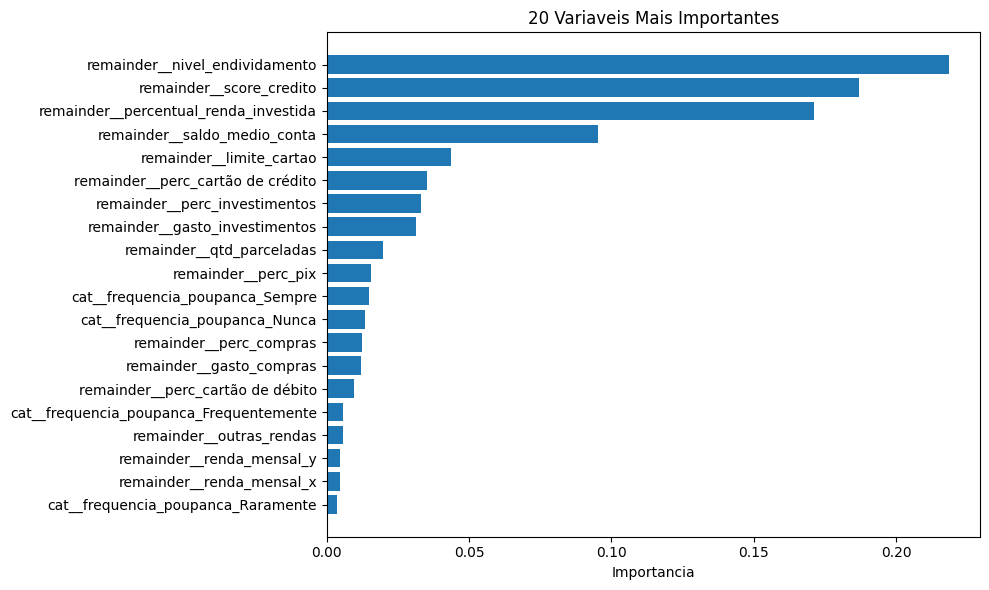

In [18]:
# ==========================================================
# GRAFICO DAS IMPORTANCIAS
# ==========================================================

plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance["Feature"].head(20),
    feature_importance["Importancia"].head(20)
)
plt.gca().invert_yaxis()
plt.title("20 Variaveis Mais Importantes")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

In [19]:
# ==========================================================
# VALIDACAO CRUZADA
# ==========================================================

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="f1_macro"
)

print("========== Validacao Cruzada ==========")
print(f"F1 Macro por Fold: {scores}")
print(f"F1 Macro Medio: {scores.mean():.4f}")
print(f"Desvio Padrao: {scores.std():.4f}")

========== Validacao Cruzada ==========
F1 Macro por Fold: [1. 1. 1. 1. 1.]
F1 Macro Medio: 1.0000
Desvio Padrao: 0.0000


In [20]:
# ==========================================================
# EXPORTAR IMPORTANCIA DAS FEATURES
# ==========================================================

feature_importance.to_csv(
    f"{BASE_MODELS}/feature_importance.csv",
    index=False,
    encoding="utf-8"
)

## Conclusao

O modelo apresentou metricas muito altas (Accuracy ~99%, F1 macro proximo de 1.0 em validacao cruzada). Observacao importante: as variaveis mais relevantes para o modelo (`nivel_endividamento`, `score_credito`, `percentual_renda_investida`) sao as mesmas utilizadas na definicao original do perfil financeiro no dataset. Ou seja, o modelo reproduz com boa fidelidade a logica de negocio que originou o rotulo, nao necessariamente descobrindo um padrao novo e independente. Isso e esperado dado como o dataset foi construido, e fica registrado aqui como limitacao/transparencia do experimento.